In [2]:
from sqlalchemy import create_engine ,text 
from sqlalchemy.engine import URL
import pandas as pd


In [4]:
from dotenv import load_dotenv
import os

load_dotenv()

url = URL.create(
        drivername="mysql+pymysql",
        username=os.getenv("DB_USER"),
        password=os.getenv("DB_PASSWORD"),
        host=os.getenv("DB_HOST"),
        port=3306,
        database="Banking_analytics"
    )
engine = create_engine(url)


In [4]:
customers = pd.read_sql("SELECT * FROM customers", engine)
accounts = pd.read_sql("SELECT * FROM accounts", engine)
loans = pd.read_sql("SELECT * FROM loans", engine)
transactions = pd.read_sql("SELECT * FROM transactions", engine)

In [6]:
loans.isnull().sum()

loan_id            0
customer_id        0
loan_type          0
loan_amount        0
interest_rate      0
tenure_months      0
emi                0
loan_status        0
loan_start_date    0
dtype: int64

In [7]:
transactions.isnull().sum()

transaction_id               0
account_id                   0
transaction_date             0
transaction_type             0
transaction_mode             0
amount                       0
balance_after_transaction    0
description                  0
dtype: int64

In [8]:
accounts.isnull().sum()

account_id              0
customer_id             0
account_number          0
account_type            0
ifsc_code               0
branch_name             0
account_opening_date    0
account_balance         0
dtype: int64

In [9]:
# print(customers.info())
# print(accounts.info())
# print(loans.info())
# print(transactions.info())

In [10]:
# round(customers.describe(),2)
# # accounts.describe()
# # loans.describe()
# # transactions.describe()

In [11]:
print("Customers :", customers.duplicated().sum())
print("Accounts :", accounts.duplicated().sum())
print("Loans :", loans.duplicated().sum())
print("Transactions :", transactions.duplicated().sum())

Customers : 0
Accounts : 0
Loans : 0
Transactions : 0


<h1>Date columns ko datetime me convert </h1>

In [12]:
customers["dob"] = pd.to_datetime(customers["dob"])

accounts["account_opening_date"] = pd.to_datetime(accounts["account_opening_date"])

loans["loan_start_date"] = pd.to_datetime(loans["loan_start_date"])

transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

In [13]:
# customers.info()
# accounts.info()
# loans.info()
# transactions.info()

<h1>Gender Distribution</h1>

In [16]:
customers["gender"].value_counts(normalize=True)*100,2

(gender
 Male      60.182
 Female    39.818
 Name: proportion, dtype: float64,
 2)

<h1>Bar Chart</h1>

<Axes: xlabel='gender'>

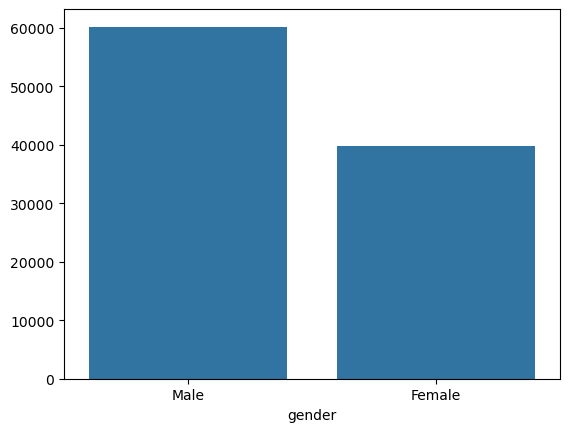

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(
    x = customers["gender"].value_counts().index,
    y = customers["gender"].value_counts().values
)

<Axes: xlabel='age', ylabel='Count'>

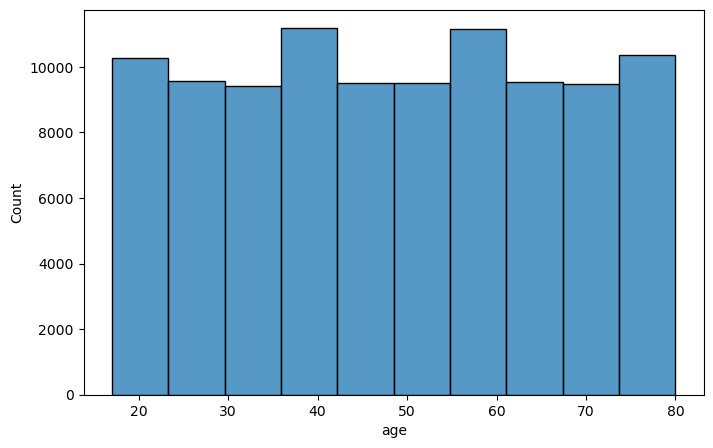

In [25]:
plt.figure(figsize = (8,5))
sns.histplot(
    customers["age"],
    bins =10
)

Text(0.5, 1.0, 'account type distribution')

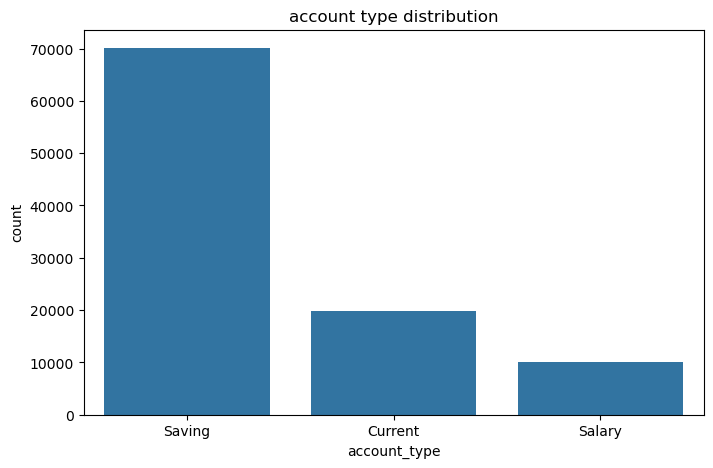

In [27]:
plt.figure(figsize=(8,5))
sns.countplot(
    data = customers,
    x = "account_type"
)
plt.title("account type distribution")

<h1>loan type distribution</h1>

In [5]:
loans["loan_type"].value_counts()

loan_type
Personal Loan     34778
Home Loan         25059
Car Loan          20043
Education Loan    10212
Business Loan      9908
Name: count, dtype: int64

Text(0, 0.5, 'number of peoples')

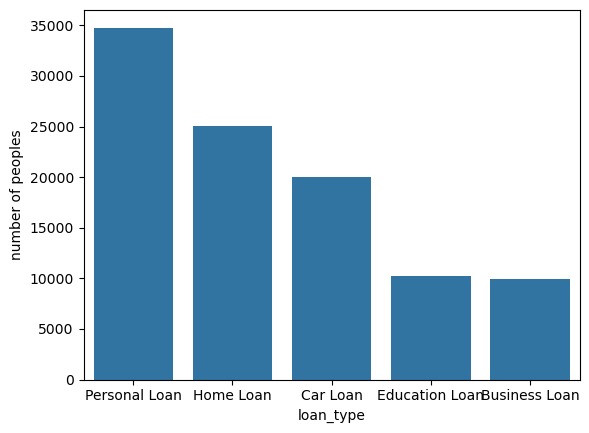

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(
    data = loans,
    x = "loan_type",
    order = loans["loan_type"].value_counts().index
)
plt.ylabel("number of peoples")

<h1>numerical analysis</h1>

In [15]:
round(accounts["account_balance"].describe(),2)

count      100000.00
mean      1824103.32
std       6590118.16
min          1000.00
25%         36000.00
50%        125000.00
75%        590000.00
max      50000000.00
Name: account_balance, dtype: float64

<Axes: xlabel='account_balance', ylabel='Count'>

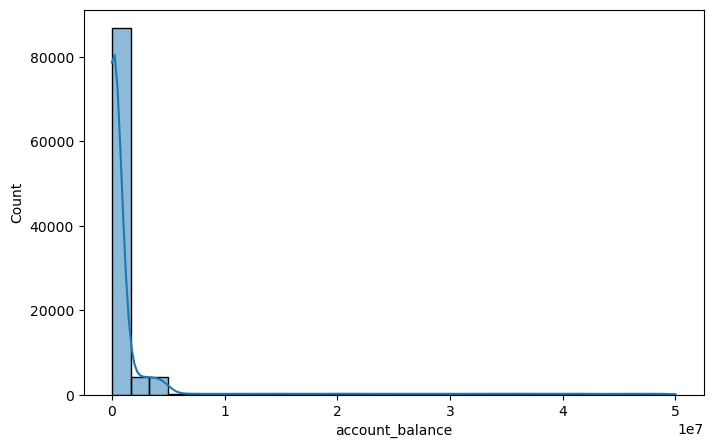

In [18]:
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(
    data =accounts,
    x = "account_balance",
    bins=30,
    kde =True
)

<Axes: xlabel='account_balance'>

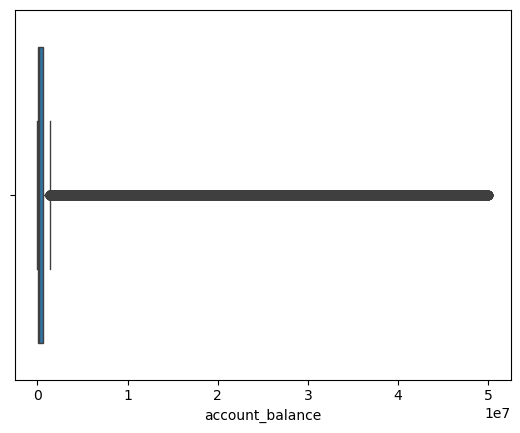

In [19]:
sns.boxplot(
    x = accounts["account_balance"]
)

<Axes: xlabel='gender', ylabel='annual_income'>

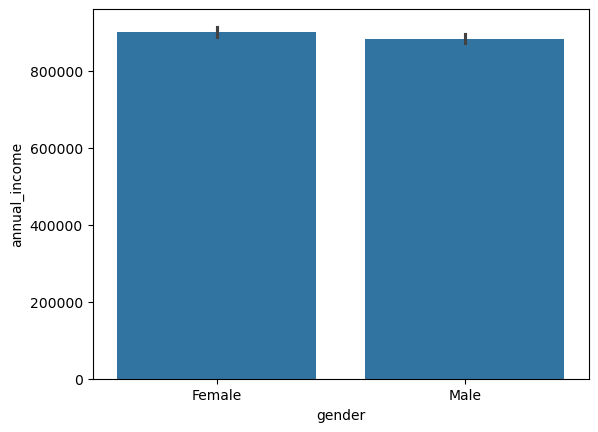

In [21]:
# This visualization compares the average annual income 
# of male and female customers. 
# It helps identify whether income levels differ across genders.
sns.barplot(
    data = customers,
    x = "gender",
    y = "annual_income"
)

<Axes: xlabel='loan_status', ylabel='cibil_score'>

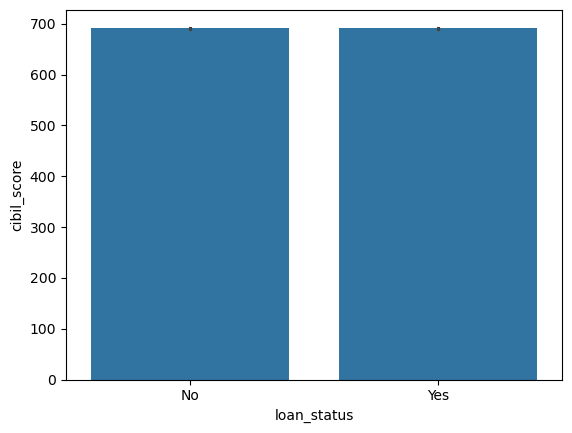

In [23]:
# Customers with better loan status generally tend to have higher CIBIL scores.
sns.barplot(
    data = customers,
    x = "loan_status",
    y = "cibil_score"
)

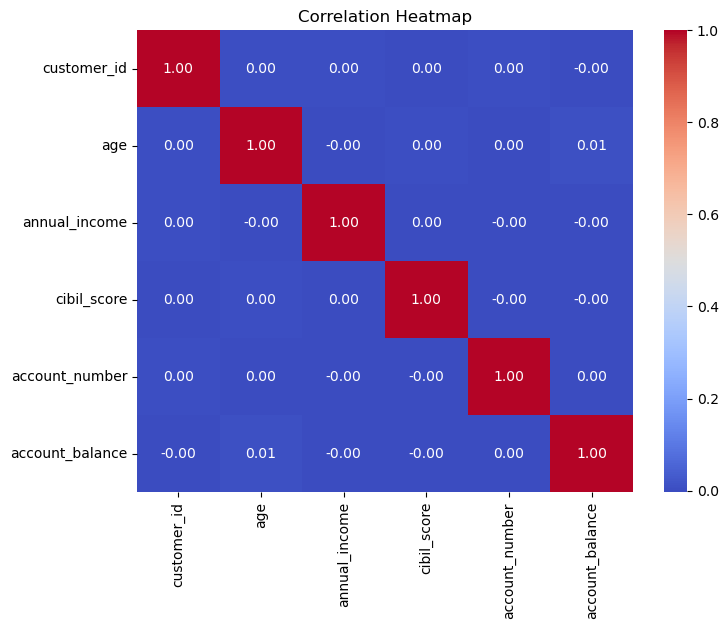

In [24]:
numeric_cols = customers.select_dtypes(include=["int64", "float64"])

corr = numeric_cols.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()